In [1]:
from astra import Astra, run_astra_with_distgen
from distgen import Generator
import os

%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

import numpy as np

import matplotlib
matplotlib.rcParams['figure.figsize'] = (12,8)

In [2]:
from astra.astra import recommended_spacecharge_mesh

In [3]:
recommended_spacecharge_mesh(1000)

{'nrad': 8, 'nlong_in': 16}

# Distgen

In [4]:
distgen_input = '$LCLS_LATTICE/distgen/models/gunb_gaussian/distgen.yaml'
G = Generator(distgen_input)
G['n_particle'] = 100000
G.run()
P0 = G.particles

# Astra

In [5]:
astra_input = os.path.expandvars('$LCLS_LATTICE/astra/models/sc_inj/astra.in')

In [6]:
A = Astra(astra_input, initial_particles=P0)
A.verbose=True
A.input['charge']['nrad']= 32
A.input['charge']['nlong_in'] = 64

In [7]:
A.run()

Initial particles written to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/astra.particles
/var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/astra.particles exists, will not symlink
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/187MHz_HighDef_March2010.dat to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/187MHz_HighDef_March2010.dat
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/APEX2cellBuncher.dat to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/APEX2cellBuncher.dat
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/9cell1300.cav
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp3j_4b76c/9cell1300.cav
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm

Loading fieldmap file /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/187MHz_HighDef_March2010.dat
Loading fieldmap file /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/APEX2cellBuncher.dat
Loading fieldmap file /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav
Loading fieldmap file /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/realbucking.dat
Loading fieldmap file /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/newSOL.dat


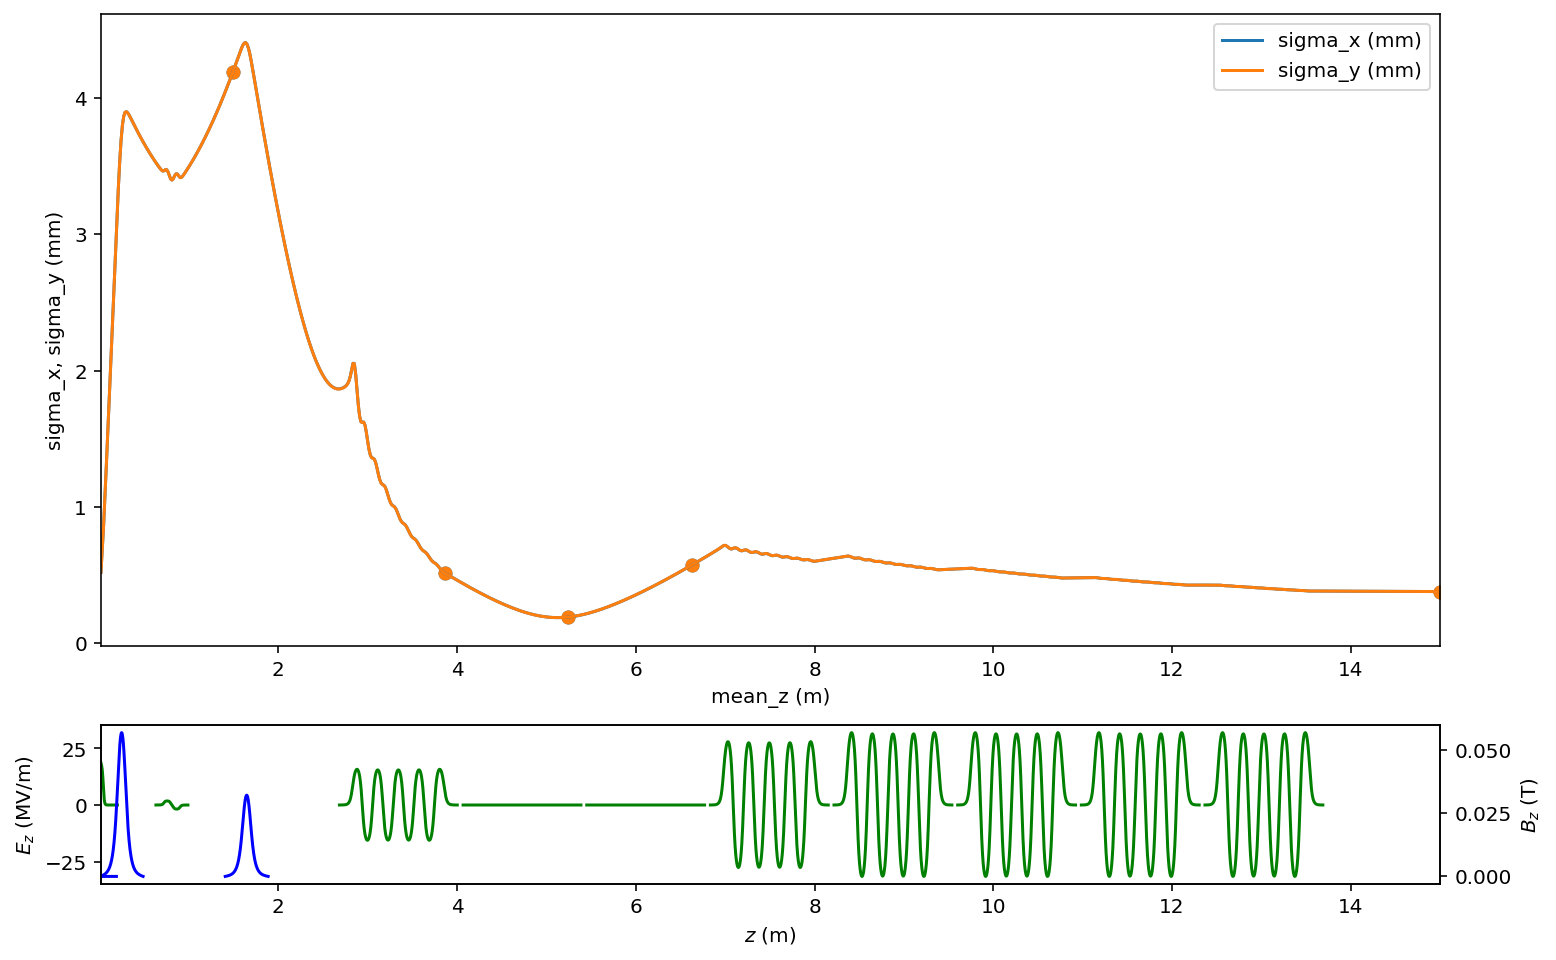

In [8]:
A.plot()

In [12]:
Pf = A.particles[-1]

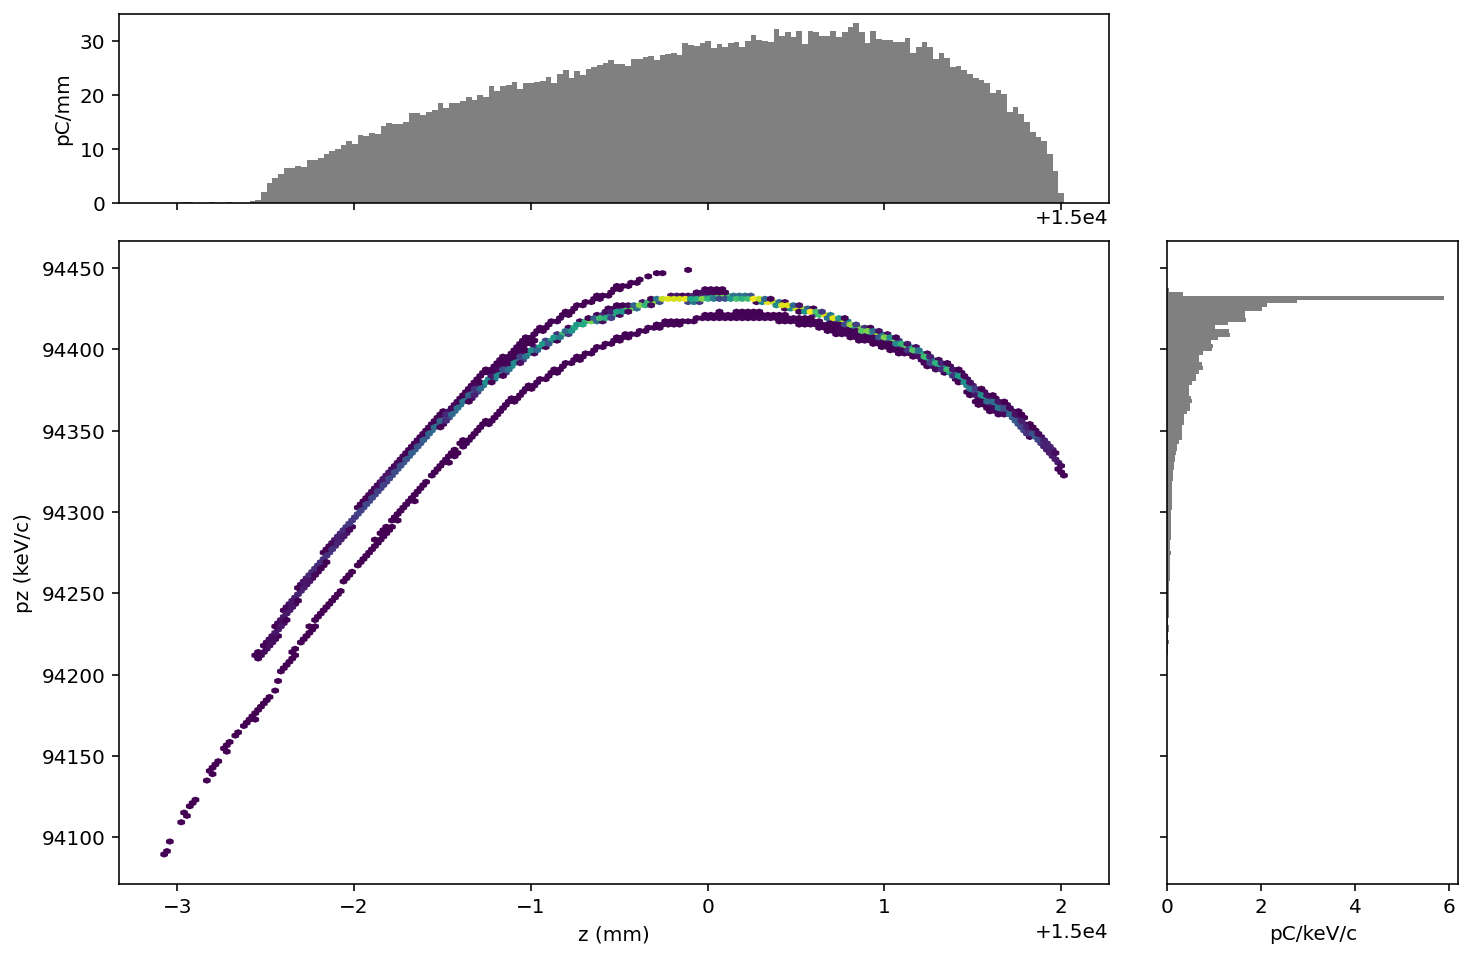

In [13]:
Pf.plot('z', 'pz')

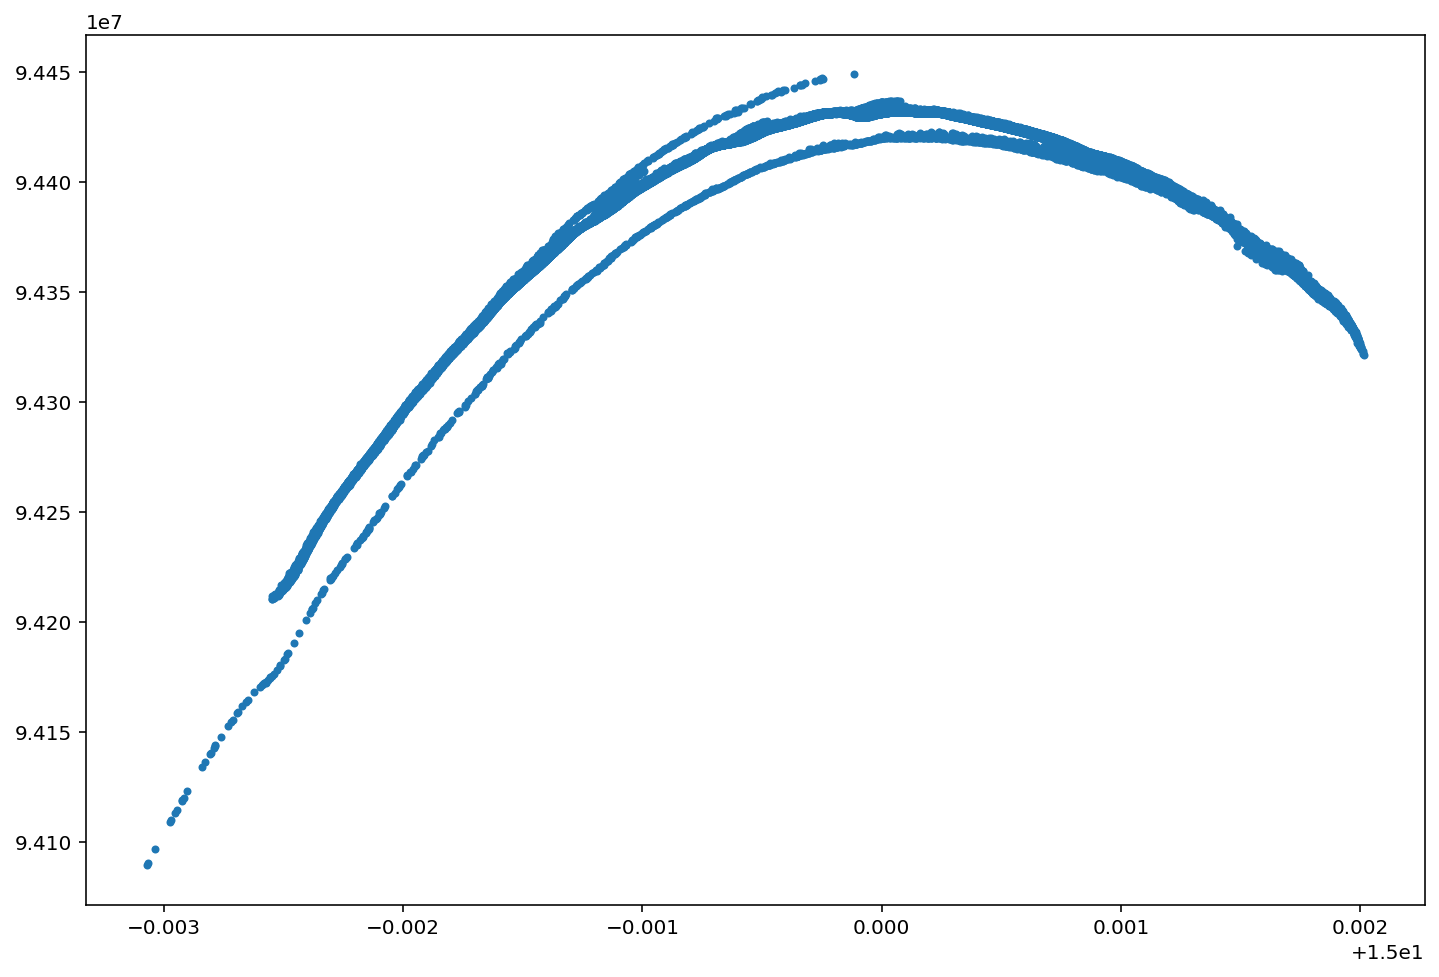

In [15]:
plt.scatter(Pf.z, Pf.pz, marker='.')